# Lab 4: Improving and Comparing Machine Learning Models 

**Name:** Shahzaib Mahar

**Roll Number:** (023-24-0282)

**GitHub Repository:** _https://github.com/smaharx/ml-forge

**Section:** H



In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,f1_score,recall_score,confusion_matrix,ConfusionMatrixDisplay)

In [50]:
#TASK1
df=pd.read_csv("D:/clean_churn.csv")
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
df=df.dropna()
df["Churn"]=df["Churn"].map({
    "Yes":1,
    "No":0
})

In [51]:
X=df.drop(columns=["Churn"])
y=df["Churn"]

In [52]:
X=pd.get_dummies(X,drop_first=True)

In [53]:
#TASK2
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
best_depth=5
dt_model=DecisionTreeClassifier(max_depth=best_depth,random_state=42)
dt_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [54]:
dt_predict=dt_model.predict(X_test)

In [55]:
dt_accuracy=accuracy_score(y_test,dt_predict)
dt_precision=precision_score(y_test,dt_predict,zero_division=0)
dt_f1_score=f1_score(y_test,dt_predict,zero_division=0)
dt_recall=recall_score(y_test,dt_predict,zero_division=0)

print("Decision Tree Baseline")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", recall_score)
print("F1-score :", dt_f1_score)



Decision Tree Baseline
Accuracy : 0.794180269694819
Precision: 0.6296296296296297
Recall   : <function recall_score at 0x0000018722B4FED0>
F1-score : 0.5845272206303725


In [56]:
#TASK3
rf_model=RandomForestClassifier(n_estimators=200,random_state=0)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)

#Task4

A random forest is actually the forest of many decision trees instead of many decision tree. because the trees are based on different samples and feature selection. and its quiet better because 1 tree can overfit thats generalize better than decision trees.

In [57]:
#Task5
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

Random Forest
Accuracy : 0.7970191625266146
Precision: 0.6466666666666666
Recall   : 0.5187165775401069
F1-score : 0.5756676557863502


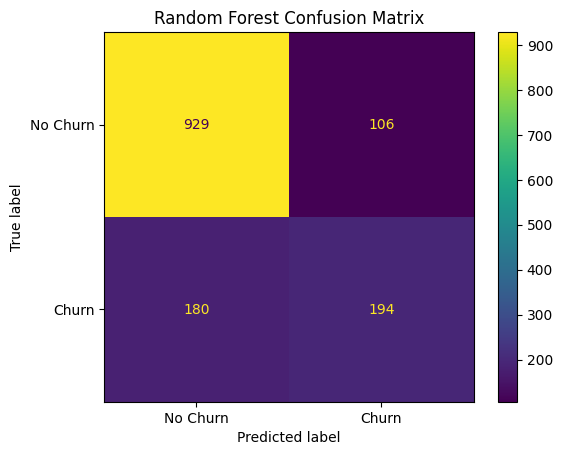

In [58]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [59]:
#task6
comparison=pd.DataFrame({
    "Model":["Decision Tree","Random Forest"],
    "Accuracy":[dt_accuracy,rf_accuracy],
    "Precision": [dt_precision,rf_precision],
    "Recall": [dt_recall,rf_recall],
    "F1-score": [dt_f1_score,rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.794180,0.629630,0.545455,0.584527
1,Random Forest,0.797019,0.646667,0.518717,0.575668


#task7

Random Forest performs slightly better in terms of accuracy and precision, while Decision Tree performs better in recall and F1-score. However, the differences between the models are marginal rather than large. Since the dataset has class imbalance, accuracy is less reliable as the main evaluation metric. F1-score and recall are more important because they provide a better indication of performance on the minority class. Based on F1-score and recall, the Decision Tree is the preferable model.


In [60]:
#task8
from sklearn.model_selection import cross_val_score
dt_cv_score=cross_val_score(dt_model,X,y,cv=5,scoring="f1")
print("Decision Trees f1 score")
print(dt_cv_score)
print("Mean", dt_cv_score.mean())
print("Standard Deviation", dt_cv_score.std())

Decision Trees f1 score
[0.56842105 0.49434572 0.48275862 0.52072968 0.53666147]
Mean 0.5205833087180272
Standard Deviation 0.030548638165675445


In [61]:
rf_cv_score=cross_val_score(rf_model,X,y,cv=5,scoring="f1")
print("Random Forest f1 score")
print(rf_cv_score)
print("Mean", rf_cv_score.mean())
print("Standard Deviation", rf_cv_score.std())

Random Forest f1 score
[0.56967841 0.55469954 0.5147929  0.56012658 0.56925419]
Mean 0.5537103224960762
Standard Deviation 0.020264768309573345


In [62]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Mean F1": [
        dt_cv_score.mean(),
        rf_cv_score.mean()
    ],
    "Std F1": [
        dt_cv_score.std(),
        rf_cv_score.std()
    ]
})

cv_comparison

,Model,Mean F1,Std F1
0,Decision Tree,0.520583,0.030549
1,Random Forest,0.553710,0.020265


#task9

The 5-fold cross-validation results provide a more reliable estimate of model performance because each model is evaluated on five different validation folds. The mean F1-score represents the average performance, while the standard deviation shows how much the performance varies between folds. If the Random Forest has a higher mean F1-score, this provides stronger evidence that it generalizes better than the Decision Tree. Cross-validation also makes the conclusion more reliable than depending on only one train/test split.


In [63]:
#task10
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
para_grid={
    "n_estimators":[100,200],
    "max_depth":[5,10],
    "min_samples_split":[2,5]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=0),
    param_grid=para_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

In [ ]:
tuned_rf = grid_search.best_estimator_

#task11

GridSearchCV tested different combinations of Random Forest hyperparameters using 5-fold cross-validation. The best combination was selected according to F1-score rather than accuracy because churn is the important minority class. The resulting parameters represent the configuration that performed best during cross-validation among the tested combinations.



In [ ]:
#task12
tuned_pred = tuned_rf.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(
    y_test,
    tuned_pred,
    zero_division=0
)
tuned_recall = recall_score(
    y_test,
    tuned_pred,
    zero_division=0
)
tuned_f1 = f1_score(
    y_test,
    tuned_pred,
    zero_division=0
)

print("Tuned Random Forest")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-score :", tuned_f1)

In [ ]:
cm_tuned = confusion_matrix(y_test, tuned_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [ ]:
#task13
final_comparison=pd.DataFrame({
    "models":["Decision Tree","Default Random Forest","Tuned Random Forest"],
    "Accuracy":[dt_accuracy,rf_accuracy,tuned_accuracy],
     "Precision": [dt_precision,rf_precision,tuned_precision],
    "Recall": [dt_recall,rf_recall,tuned_recall],
    "F1-score": [dt_f1_score,rf_f1,tuned_f1]
})
final_comparison

In [ ]:
#task13
best_model = final_comparison.loc[
    final_comparison["F1-score"].idxmax()
]

print("Best model based on F1-score:")
print(best_model)

The final comparison includes the original Decision Tree, the default Random Forest, and the tuned Random Forest. The models are compared using all four evaluation metrics instead of relying only on accuracy. The model with the strongest F1-score provides the best balance between identifying churn customers and avoiding incorrect churn predictions. The final choice should therefore consider F1-score together with recall, precision, and cross-validation results.


In [ ]:
#task14
importances = tuned_rf.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

In [ ]:
#task15
top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(8, 6))

plt.barh(
    top_features.index,
    top_features.values
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Tuned Random Forest")

plt.show()

In [ ]:
print("Top 5 Important Features:")
print(feature_importance.head(5))

The feature importance plot shows which features contributed most to the Random Forest's predictions. The top features provide an indication of which customer characteristics are most useful for predicting churn. Features such as tenure, contract type, monthly charges, and total charges may be important because customer commitment and billing behavior can be related to churn. These results can be compared with the EDA from Lab 2 and the Decision Tree from Lab 3 to see whether similar patterns were identified.


In [ ]:
final_comparison.sort_values(
    by="F1-score",
    ascending=False
)

In [ ]:
print("Decision Tree CV F1:",
      dt_cv_score.mean())

print("Random Forest CV F1:",
      rf_cv_score.mean())

print("Tuned Random Forest CV F1:",
      grid_search.best_score_)

Based on the test-set metrics and cross-validation results, the Tuned Random Forest is selected as the final model because it provides a strong balance between precision, recall, and F1-score. Unlike the single Decision Tree, the Random Forest combines multiple trees and therefore can generalize better. The hyperparameter tuning process further searches for a configuration that performs well using cross-validation rather than relying on one training result. Therefore, the final model is selected based on both test performance and cross-validation evidence.


In [ ]:
#task16
submission_df = pd.read_csv("D:/Telco-Customer-Churn.csv")

submission_df["TotalCharges"] = pd.to_numeric(
    submission_df["TotalCharges"],
    errors="coerce"
)

submission_df = submission_df.dropna()

customer_ids = submission_df["customerID"]

In [ ]:
submission_features = submission_df.drop(
    columns=["customerID", "Churn"]
)

submission_features = pd.get_dummies(
    submission_features,
    drop_first=True
)

In [ ]:
submission_features = submission_features.reindex(
    columns=X.columns,
    fill_value=0
)

In [ ]:
submission_predictions = tuned_rf.predict(
    submission_features
)

In [ ]:
submission_predictions = np.where(
    submission_predictions == 1,
    "Yes",
    "No"
)

In [ ]:
submission = pd.DataFrame({
    "customerID": customer_ids.values,
    "Churn": submission_predictions
})

submission.head()

In [ ]:
submission.to_csv(
    "submission.csv",
    index=False
)

In [ ]:
print("Submission shape:", submission.shape)

print("\nColumns:")
print(submission.columns)

print("\nChurn predictions:")
print(submission["Churn"].value_counts())

#task17

In this lab, I compared a Decision Tree with a default Random Forest and a tuned Random Forest for predicting customer churn. The Random Forest models provided a stronger ensemble approach by combining multiple Decision Trees and reducing the limitations of relying on a single tree. I used accuracy, precision, recall, F1-score, confusion matrices, and 5-fold cross-validation to compare the models more reliably. Hyperparameter tuning was performed using GridSearchCV to find a better Random Forest configuration based on F1-score. The final model was selected using both test-set performance and cross-validation results rather than training performance alone. However, the model still has limitations such as class imbalance and the possibility of improving performance through better feature engineering and additional algorithms.


#task18

If I had more time, I would try additional algorithms such as Logistic Regression, Gradient Boosting, or XGBoost and compare them with the Random Forest. I would also investigate class imbalance using techniques such as class weights or resampling. More extensive hyperparameter tuning could potentially improve the model further. Finally, I would perform additional feature engineering and analyze whether the most important features remain consistent across different models.
ask 18

